In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
checkpoint_dir = Path("data") / "ch03_checkpoints"

In [3]:
json_files = sorted(
    checkpoint_dir.glob("*.json"),
    key=lambda x: x.stat().st_ctime,
    #key=lambda x: int(x.name.split("-")[1]),
    reverse=False,
)

if len(json_files) > 2:
    print(f"--> Loaded: files={len(json_files)}, start={json_files[0].name}, end={json_files[-1].name}")

epochs, train_losses, val_losses = [], [], []

for f in json_files:
    #print(f"---> file: {f}")
    data = json.loads(f.read_text())

    epoch = f.name.replace("checkpoint_", "").replace(".json", "").split("-")[0]

    epochs.append(int(epoch))
    train_losses.append(data['train_loss'])
    val_losses.append(data['validation_loss'])

--> Loaded: files=135, start=checkpoint_001100.json, end=checkpoint_100000.json


In [4]:
df = pd.DataFrame({
    "epochs": epochs,
    "train_losses": train_losses,
    "val_losses": val_losses,
})

#print(df)
df

,epochs,train_losses,val_losses
0,1100,4.331566,4.356945
1,1200,4.284533,4.322316
2,1300,4.242753,4.279043
3,1400,4.211816,4.251267
4,1500,4.178031,4.222612
...,...,...,...
130,96000,2.592801,2.751199
131,97000,2.592304,2.751330
132,98000,2.585011,2.744453
133,99000,2.585327,2.746492


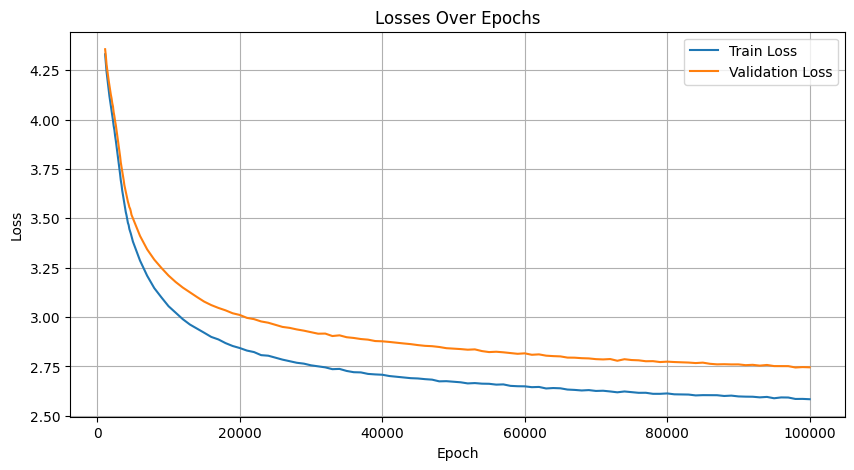

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, label="Train Loss") # marker='o'
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses Over Epochs")
plt.legend()
plt.grid()
plt.show()